In [1]:
import pandas as pd

# all these daatsets good when asking questions to trained llm not pre training

# genralised articles
dftr = list(pd.read_parquet('SFT dataset/not used/ehovy:race/train-00000-of-00001.parquet').drop_duplicates(subset='example_id')['article'])
dfts = list(pd.read_parquet('SFT dataset/not used/ehovy:race/test-00000-of-00001.parquet').drop_duplicates(subset='example_id')['article'])
dfv = list(pd.read_parquet('SFT dataset/not used/ehovy:race/validation-00000-of-00001.parquet').drop_duplicates(subset='example_id')['article'])
race_txt = dftr+dfts+dfv

# Proper start and functional format missing
dftr = list(pd.read_parquet('SFT dataset/not used/Story Sparks QA/train-00000-of-00001-d88b895f971fd4d3.parquet').drop_duplicates(subset=['story_name','section_id'])['section_text'])
dfts = list(pd.read_parquet('SFT dataset/not used/Story Sparks QA/test-00000-of-00001-b223c8e9e4044f34.parquet').drop_duplicates(subset=['story_name','section_id'])['section_text'])
dftv = list(pd.read_parquet('SFT dataset/not used/Story Sparks QA/val-00000-of-00001-e4656dfad5a4aab8.parquet').drop_duplicates(subset=['story_name','section_id'])['section_text'])
story_sparks = dftr+dfts+dfv

In [2]:
import random

file_path = 'Datasets Pretraining/TinyStories-train.txt'
other_sample_size = 20000
onceupon_sample_size = 1000
once_sample_size = 1000

# Reservoirs for sampling
once_sample = []
onceupon_sample = []
other_sample = []

# Counters for reservoir sampling
once_count = 0
onceupon_count = 0
other_count = 0

import random

prompts = [
    "Start a story with",
    "Write a story beginning with",
    "Tell a story that starts with",
    "Begin a story using",
    "Create a story ",
    "Compose a story that opens with",
    "Write a short story beginning with",
    "Start your story with the phrase",
    "Craft a narrative ",
    "Write a tale that starts with",
    "Start writing a story ",
    "Write a paragraph starting with",
    "Begin your story with the line",
    "Write a fiction piece starting with",
    "Create a short narrative beginning with",
    "Start a creative story ",
    "Write a scene that begins with",
    "Compose a short story ",
    "Write an imaginative story beginning with",
    "Start a fictional story "
]

with open(file_path, 'r', encoding='utf-8') as file:
    buffer = []
    for line in file:
        buffer.append(line)
        if "<|endoftext|>" in line:  # End of one story
            story = "".join(buffer).replace("<|endoftext|>", "").strip()
            buffer = []

            if not story:
                continue

            # Decide which group
            if story.startswith("Once upon a time"):  # Check this first
                onceupon_count += 1
                if len(onceupon_sample) < onceupon_sample_size:
                    onceupon_sample.append(story) # random.choice(prompts) + ' ' + 
                else:
                    idx = random.randint(0, onceupon_count - 1)
                    if idx < onceupon_sample_size:
                        onceupon_sample[idx] = story

            elif story.startswith("Once"):
                once_count += 1
                if len(once_sample) < once_sample_size:
                    once_sample.append(story)
                else:
                    idx = random.randint(0, once_count - 1)
                    if idx < once_sample_size:
                        once_sample[idx] = story

            else:
                other_count += 1
                if len(other_sample) < other_sample_size:
                    other_sample.append(story)
                else:
                    idx = random.randint(0, other_count - 1)
                    if idx < other_sample_size:
                        other_sample[idx] = story

# Combine and shuffle
tiny_stories = onceupon_sample + once_sample + other_sample
random.shuffle(tiny_stories)

print(f"Sample size: {len(tiny_stories)} (Onceupon: {len(onceupon_sample)}, Once: {len(once_sample)}, Others: {len(other_sample)})")
del(once_sample)
del(other_sample)
del(onceupon_sample)

Sample size: 22000 (Onceupon: 1000, Once: 1000, Others: 20000)


In [3]:
import pandas as pd

fable_df = pd.read_parquet('Datasets Pretraining/klaus/klusai-ds-tf1-en-3m_test_00000.parquet')
fable_df['full_content'] = fable_df['fable'].str.strip().str.lower()
fable_ts = list(fable_df[fable_df['full_content'].str.split().str.len() < 250].reset_index(drop=True)['full_content'])
del(fable_df)

fable_df = pd.read_parquet('Datasets Pretraining/klaus/klusai-ds-tf1-en-3m_validate_00000.parquet')
fable_df['full_content'] = fable_df['fable'].str.strip().str.lower()
fable_val = list(fable_df[fable_df['full_content'].str.split().str.len() < 250].reset_index(drop=True)['full_content'])
del(fable_df)

In [4]:
import json
import pandas as pd

fta_tr = []
with open("SFT dataset/fairy tale qa/train.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            fta_tr.append(json.loads(line))
df_fta_tr = pd.DataFrame(fta_tr)[['content']]

fta_ts = []
with open("SFT dataset/fairy tale qa/test.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            fta_ts.append(json.loads(line))
df_fta_ts = pd.DataFrame(fta_ts)[['content']]

fta_val = []
with open("SFT dataset/fairy tale qa/valid.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            fta_val.append(json.loads(line))
df_fta_val = pd.DataFrame(fta_val)[['content']]

df_fta = pd.concat([df_fta_tr,df_fta_ts,df_fta_val]).reset_index(drop=True)
fairy_tale = list(df_fta.drop_duplicates()['content'])

del(fta_tr)
del(fta_ts)
del(fta_val)
del(df_fta)

In [5]:
len(tiny_stories),len(fable_ts),len(fable_val),len(race_txt),len(story_sparks),len(fairy_tale)

(22000, 12626, 12532, 27931, 5104, 4260)

In [6]:
all_texts = tiny_stories + fable_ts + fable_val + race_txt + story_sparks + fairy_tale
del(fable_ts)
del(fable_val)
del(tiny_stories)
del(race_txt)
del(story_sparks)

In [7]:
import numpy as np
from tqdm.auto import tqdm
import re

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

# Combine summary + dialogue and split on whitespace
raw_lens = [len(clean_text(s).split()) for s in tqdm(all_texts, total=len(all_texts))]

lens = np.array(raw_lens)

# Print summary stats
def pct(x): return np.percentile(lens, x)

print(f"Total examples    : {len(lens):,}")
print(f"Min / Max words   : {lens.min()} / {lens.max()}")
print(f"Mean ± std        : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- Percentiles (word count per raw text pair) ---")
for p in [50, 60, 70, 80, 90, 95, 99]:
    print(f"{p:>3}% : {pct(p):.0f} words")

del(lens)
del(raw_lens)

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 84453/84453 [00:03<00:00, 24022.33it/s]

Total examples    : 84,453
Min / Max words   : 2 / 1558
Mean ± std        : 245.6 ± 92.3
--- Percentiles (word count per raw text pair) ---
 50% : 244 words
 60% : 248 words
 70% : 265 words
 80% : 302 words
 90% : 349 words
 95% : 395 words
 99% : 560 words


In [8]:
import numpy as np
from tqdm.auto import tqdm
import re

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text

MAX_LEN = 400

stories = []

for i in all_texts:
    try:
        if len(clean_text(i).strip().split()) < MAX_LEN: 
            stories.append(clean_text(i))
    except:
        pass

del(all_texts)

8000



12000



16000



20000



24000





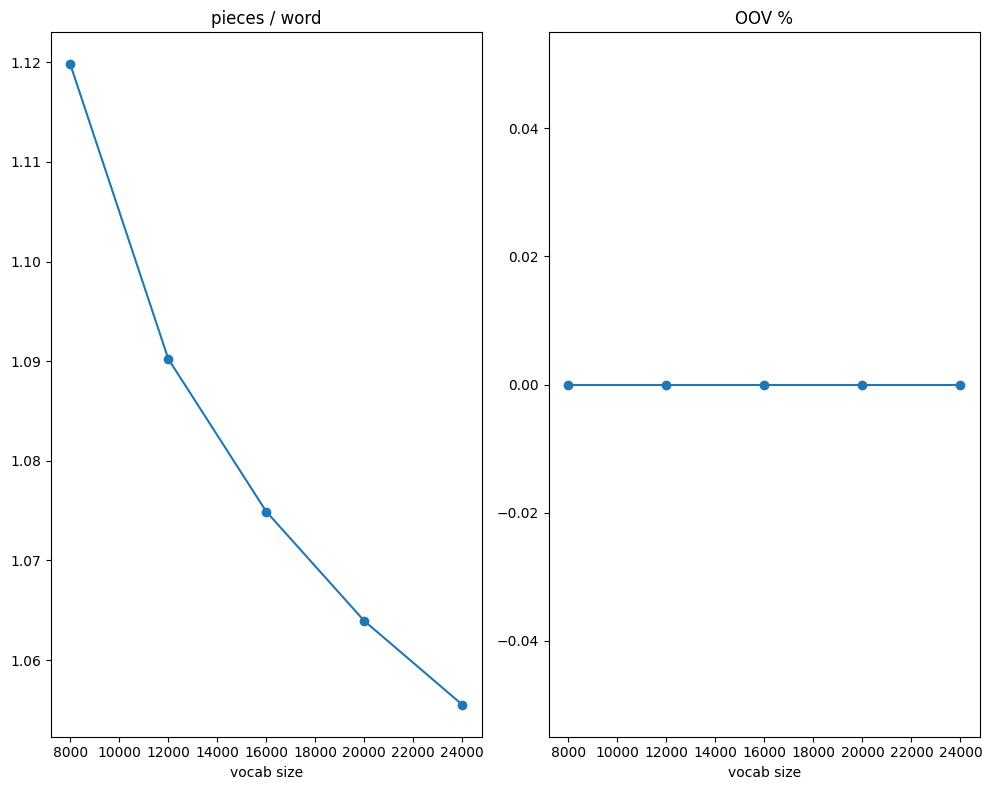

In [9]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
import matplotlib.pyplot as plt
        
split = int(0.95*len(stories))
train_texts, valid_texts = stories[:split],stories[split:]

def train_tokenizer(text_iter, vocab_size: int) -> Tokenizer:
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size,
                                  min_frequency=2,
                                  special_tokens=["[UNK]"])
    tok.train_from_iterator(text_iter, trainer)
    return tok

def avg_pieces_per_word(tok: Tokenizer, texts) -> float:
    pieces = words = 0
    for t in texts:
        ids   = tok.encode(t).ids
        pieces += len(ids)
        words  += len(t.split())
    return pieces / words

vocab_sizes = [8000, 12000, 16000, 20000, 24000]
pieces_per_word, oov_rate = [], []

for k in vocab_sizes:
    print(k)
    tok = train_tokenizer(train_texts, k)

    # 1) average sub-words per word on validation set
    pieces_per_word.append(avg_pieces_per_word(tok, valid_texts))

    # 2) OOV percentage on validation set
    unk_id = tok.token_to_id("[UNK]")
    total = unk = 0
    for t in valid_texts:
        ids   = tok.encode(t).ids
        total += len(ids)
        unk   += sum(id_ == unk_id for id_ in ids)
    oov_rate.append(100 * unk / total)

# ── plot ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(vocab_sizes, pieces_per_word, marker='o')
plt.title("pieces / word"); plt.xlabel("vocab size")

plt.subplot(1,2,2)
plt.plot(vocab_sizes, oov_rate, marker='o')
plt.title("OOV %"); plt.xlabel("vocab size")

plt.tight_layout(); plt.show()

In [10]:
VOCAB_SIZE = 12000
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]','[IMG_TOKEN]']

In [11]:
import re
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers.processors import TemplateProcessing

# Initialize and train
tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=VOCAB_SIZE, special_tokens=SPECIAL_TOKENS)
tokenizer.train_from_iterator(stories, trainer=trainer)

# ── Configure post-processing ────────────────────────────────
pad_id = tokenizer.token_to_id("[PAD]")
unk_id = tokenizer.token_to_id("[UNK]")
bos_id = tokenizer.token_to_id("[BOS]")
eos_id = tokenizer.token_to_id("[EOS]")
sep_id = tokenizer.token_to_id("[SEP]")
img_token_id = tokenizer.token_to_id("[IMG_TOKEN]")

tokenizer.post_processor = TemplateProcessing(
    single='$A',
    special_tokens=[],
)

Total samples    : 10,000
Min / Max tokens : 25 / 598
Mean ± std       : 294.5 ± 94.4
--- percentiles (tokens) ---
 50% : 301
 90% : 420
 95% : 458
 99% : 513


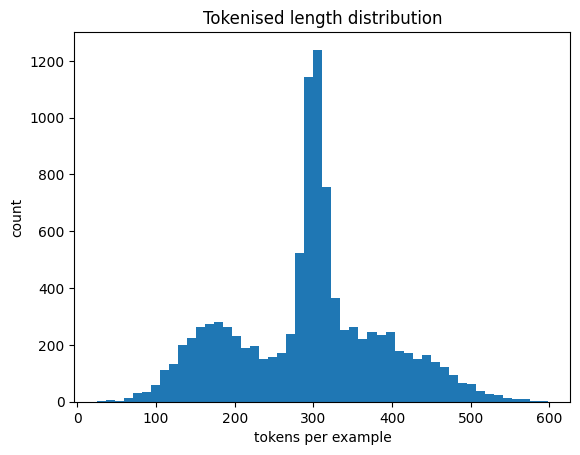

In [12]:
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# 0)  Make sure `tok` points to the FINAL tokenizer
#     → trained on the full corpus with your chosen vocab_size
# ------------------------------------------------------------
tok = tokenizer          # whatever variable you use

# ------------------------------------------------------------
# 1)  Get token counts for every example
#     (here: concatenate summary + dialogue; split if you want)
# ------------------------------------------------------------
lens = []
rnd_story = random.choices(stories, k=10000) 
for txt in rnd_story:
    ids   = tok.encode(txt).ids
    lens.append(len(ids))

lens = np.array(lens)

# ------------------------------------------------------------
# 2)  Print key stats
# ------------------------------------------------------------
def pct(x): return np.percentile(lens, x)

print(f"Total samples    : {len(lens):,}")
print(f"Min / Max tokens : {lens.min()} / {lens.max()}")
print(f"Mean ± std       : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- percentiles (tokens) ---")
for p in (50, 90, 95, 99):
    print(f"{p:>3}% : {pct(p):.0f}")

# ------------------------------------------------------------
# 3)  Quick histogram    (no seaborn, single plot, no colors set)
# ------------------------------------------------------------
plt.hist(lens, bins=50)
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.title("Tokenised length distribution")
plt.show()

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
import random

BATCH_SIZE = 32
BLOCK_SIZE = 128  # your context length

class RandomWindowTextDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size, bos_id, eos_id):
        """
        texts:     List[str]             — your raw documents
        tokenizer: huggingface-style with .encode(text).ids
        block_size: int                 — number of tokens per sample
        bos_id, eos_id: int             — special tokens, if you want them
        """
        self.texts = texts
        self.tok   = tokenizer
        self.bs    = block_size
        self.bos   = bos_id
        self.eos   = eos_id

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        doc = random.choice(self.texts)

        # 2) tokenize on-the-fly
        ids = self.tok.encode(doc).ids

        L = len(ids)
        # 3) if too short, skip-and-retry by recursion
        if L < self.bs:
            return self.__getitem__(idx)

        # 4) pick random window start
        start = random.randint(0, L - self.bs)
        window = ids[start : start + self.bs - 1]

        # 5) build x, y
        x = [self.bos] + window  
        y = window + [self.eos]  

        ids_t = torch.tensor(x, dtype=torch.long)
        labels_t = torch.tensor(y, dtype=torch.long)
    
        return {"input_ids": ids_t,"labels": labels_t}

# --- wrap in DataLoader ---
dataset = RandomWindowTextDataset(
    texts=stories,
    tokenizer=tokenizer,
    block_size=BLOCK_SIZE,
    bos_id=bos_id,    # or None
    eos_id=eos_id     # or None
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,    # no need: randomness is inside __getitem__
    drop_last=True
)
del(stories)
del(dataset)

In [19]:
vocab = tokenizer.get_vocab()           # indices 0 … V

id_to_token = {idx: tok for tok, idx in vocab.items()}

# 2) Decoder: drop PADs, replace unknown IDs with '?'
def decode_token_ids(token_ids: list[int]) -> str:
    tokens = []
    for tid in token_ids:
        if tid == pad_id:
            continue
        tokens.append(id_to_token.get(tid, '?'))
    return ' '.join(tokens)

# Take one batch
batch = next(iter(loader))

input_ids = batch['input_ids']   # shape: [B, MAX_LEN]
labels    = batch['labels']      # shape: [B, MAX_LEN]

for i in range(input_ids.size(0)):
    ids_row = input_ids[i].tolist()
    lbl_row = labels[i].tolist()

    print(f"\n🟢 Sample {i+1}")
    print("  Input IDs: ", ids_row)
    print("  Decoded:   ", decode_token_ids(ids_row))  # Assumes you have this function defined
    print("  Label. :   ", decode_token_ids(lbl_row))  # Assumes you have this function defined
    print("  Label IDs: ", lbl_row)


🟢 Sample 1
  Input IDs:  [2, 295, 6944, 256, 228, 111, 1555, 19, 7, 78, 223, 221, 131, 1823, 289, 110, 3511, 19, 125, 110, 915, 17, 111, 978, 1052, 3439, 17, 118, 111, 2133, 12, 88, 1960, 643, 115, 5399, 19, 398, 322, 110, 453, 189, 145, 1182, 17, 70, 1206, 1836, 915, 260, 115, 295, 19, 7, 542, 156, 256, 147, 17, 233, 315, 177, 194, 1514, 19, 7, 157, 223, 427, 300, 118, 1935, 111, 3030, 213, 111, 2133, 17, 750, 760, 17, 2361, 122, 613, 17, 200, 111, 1836, 12, 88, 364, 828, 118, 111, 11565, 1250, 3982, 4378, 295, 476, 19, 300, 17, 111, 2133, 118, 111, 1836, 3498, 1857, 111, 978, 118, 1873, 1547, 111, 3030, 19, 111, 1555, 17, 317, 220, 1284, 111, 2520, 1171, 300]
  Decoded:    [BOS] him refuse help from the villagers . " i can do it myself !" he growled . as he swam , the storm grew worse , and the walrus ' s strength began to fade . just when he thought all was lost , a friendly seal swam up to him . " let me help you , friend ," she said gently . " we can work together and reach the s

In [20]:
from model import *

device='mps'

class BuildTransformer(torch.nn.Module):
    def __init__(self, *, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size=input_vocab_size, d_model=d_model)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                               input_vocab_size=input_vocab_size, dropout_rate=dropout_rate)

    def forward(self, inputs):
        x = inputs
        # Create padding mask (True for padding tokens, False otherwise)
        pad_mask = (x == 0)  # Assuming padding token is 0, as in TokenEmbedding's padding_idx
        x = self.token_embedding(x)
        x = self.decoder(x, pad_mask=pad_mask)
        return x

# Example instantiation
num_layers = 3
d_model = 256
num_heads = 8  # 32 dim per head
dropout_rate = 0.1

model = BuildTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=VOCAB_SIZE,
    dropout_rate=dropout_rate
)

model.to(device)

# Build weights by running a forward pass
dummy = torch.zeros((1, BLOCK_SIZE), dtype=torch.int32).to(device)
_ = model(dummy)

In [21]:
print("Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Trainable Parameters: {total_params:,}")

Trainable Parameters:
------------------------------------------------------------
Parameter: token_embedding.embedding.weight                   Shape: torch.Size([12000, 256]) Parameters: 3072000
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wq.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wk.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wv.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wo.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.rmsnorm.scale Shape: torch.Size([256])    Parameters: 256
Parameter: decoder.dec_layers.0.ffn.swiglu.lin1.weight        Shape: torch.Size([1024, 256]) Parameters: 262144
Parameter: decoder.dec_layers.0.ffn.swiglu.lin2.weight        Shape: torch.Size([256, 512]) Parameters: 131072
Para

In [22]:
print("Non Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in model.named_parameters():
    if not param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Non Trainable Parameters: {total_params:,}")

Non Trainable Parameters:
------------------------------------------------------------
------------------------------------------------------------
Total Non Trainable Parameters: 0


In [23]:
def encode_input(text: str) -> torch.Tensor:
    """
    Returns [BOS] dialogue [EOS] *without* any padding.
    """
    ids = [bos_id] + tokenizer.encode(clean_text(text)).ids      
    return torch.tensor(ids, dtype=torch.int32)     # 1-D tensor

@torch.no_grad()
def generate_summary(
    text_ids: torch.Tensor,
    model: torch.nn.Module,
    max_new: int = 120,
    temperature: float = 1,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Generate tokens auto-regressively: [BOS] text [EOS]
    """
    model.eval()

    prompt = text_ids.unsqueeze(0).to(device)  # (1, T)
    for _ in range(max_new):
        if prompt.shape[1] > MAX_LEN:                
            break

        logits = model(prompt)[:, -1, :] / temperature
        next_id = torch.distributions.Categorical(logits=logits).sample().unsqueeze(0)
        prompt = torch.cat([prompt, next_id], dim=1)

        if next_id[0, 0] == eos_id:
            break

    return prompt.squeeze(0)

def display_text(text: str, model, temp=1, device="cpu"):
    # 1. Encode input
    text_ids = encode_input(text)

    # 2. Generate full sequence
    full_ids = generate_summary(text_ids, model, temperature=temp, device=device)

    # 3. Convert to list
    full_ids_list = full_ids.tolist()

    # 4. Decode
    text_str = decode_token_ids(full_ids_list)

    # 5. Print
    print("Text:", text_str)

In [24]:
from torch.optim.lr_scheduler import _LRScheduler
import math
from tqdm import tqdm

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-3.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]
    
EPOCHS = 10
LEARNING_RATE_MIN = 1e-6
LEARNING_RATE_MAX = 1e-3
WARMUP_RATIO = 0.1

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9, 0.98), eps=1e-9) # Initial LR can be max, scheduler will adjust
criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)

# --- Calculate total steps and initialize scheduler ---
total_steps = len(loader) * EPOCHS
scheduler = CustomLRScheduler(
    optimizer,
    total_steps=total_steps,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss = tot_correct = tot_tokens = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
    for batch in pbar:
        ids  = batch["input_ids"].to(device)          # (B, T)
        tgt  = batch["labels"].to(device)             # (B, T)

        optimizer.zero_grad()
        logits = model(ids)                           # (B, T, V)

        # ---- loss ----
        loss = criterion(logits.view(-1, logits.size(-1)), tgt.view(-1))  # (B * T, V) & (B*T,)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # ---- metrics (no grad) ----
        with torch.no_grad():
            preds   = logits.argmax(-1)
            valid   = (tgt != pad_id)                 # bool mask
            correct = (preds == tgt) & valid
            n_tok   = valid.sum().item()

            tot_correct += correct.sum().item()
            tot_tokens  += n_tok
            tot_loss    += loss.item() * n_tok        # de‑average

        pbar.set_postfix(
            loss=f"{tot_loss / tot_tokens:.4f}",
            acc=f"{tot_correct / tot_tokens:.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.6f}"
        )

    display_text('john saw coffee in kitchen',model,device='mps')

Epoch 1/5: 100%|██████████| 2515/2515 [07:45<00:00,  5.40it/s, acc=0.2340, loss=4.7544, lr=0.000717]


Text: [BOS] jo h n saw coffee in kitchen . Nobody was having some stayed in the church with many different kinds of interesting success through our bed . So it gave us soon a football while they were trying to work together to send a big machine , maybe they would send the chocolate into detail ," Mrs S ear decides to help them Mark pick . Mr . S Green mp kin felt . " Another mind $ 18 miles napkin which would grow and focus on QQ matters ," I wrote a lot and go to bed to the University B au I encourage people to get home now TV . I usually like when I was to be busy , if the students stayed home


Epoch 2/5: 100%|██████████| 2515/2515 [07:56<00:00,  5.28it/s, acc=0.3118, loss=3.7463, lr=0.000368]


Text: [BOS] jo h n saw coffee in kitchen royal flowers and offered help . She whispered , " I don ' t care this thing . I don ' t know you are doing it too . I kept going to visit you ." Alice showed her mom how to put the perfect fruit in the verse room ? The pink Lily saw the mess ! The next day , the bug wanted to leave its empty walk . She grabbed the pot and flew to the bench . She was curious and forgot about it . She began to spin a tear with a microphone and a bite try to climb the Dou clearing . She reached out her hand and lifted it off . She lifted


Epoch 3/5: 100%|██████████| 2515/2515 [07:44<00:00,  5.41it/s, acc=0.3274, loss=3.5877, lr=0.000190]


Text: [BOS] jo h n saw coffee in kitchen . He was wearing a doll with many marks attached to their little items and then turned to her room . " Everything was trinkets !" Fred said . Julie was very happy and excited to show each of him . purchase called correctly , Bo din ism dropped from the car and was to go to the living room . When she got that the trophy , Michael showed him how to pick it up and they found it was in a library and that he saw the trash open door to the chair . Ron put a hed in the counter folk , and praised her teacher for being very professional . Up in , Ella ' s


Epoch 4/5: 100%|██████████| 2515/2515 [07:43<00:00,  5.43it/s, acc=0.3354, loss=3.5130, lr=0.000098]


Text: [BOS] jo h n saw coffee in kitchen and asked , " What should it be ? Is it a lemon ?" Her mom replied , " I want ice cream . If I take it away , I can ' t have it ." Then , she pushed the ripe teddy bear to the buzzing . There , she saw a naughty dog and some were very excited . The dog ran around and shouted , " Let ' s take this spot . Open me , this is the dessert ." They made the cake look yummy cookie with their small dogs . They were so happy to watch the store . They played together and shared the popcorn . Then , they opened the door


Epoch 5/5: 100%|██████████| 2515/2515 [07:44<00:00,  5.42it/s, acc=0.3385, loss=3.4844, lr=0.000051]


Text: [BOS] jo h n saw coffee in kitchen . He closed it , and he set the big round one right there after ons , and put those 27 percent left . My cooperate wasn ' t allowed electricity for adults . Each way , my wife included a husband earning . I found a huge bathroom hanging from a symbol with one ---- so I was shocked by no ons to watch the car as full of sparkles as it was also a powerful body . I thought we had strict ly gained the ments of 100 years to adults that played all day each day despite tightly . But I spread my children so fat into wondered why I felt it was important to ask for


In [26]:
display_text('once in a mountain',model,device='mps',temp=1)

Text: [BOS] once in a mountain cave , a small silver storm rolled in , and under the cold hills , setting air through the clouds . the stalk huddled together , watching the seagull see a small creature in the distance . they saw the kind lion ' s laz iness . birds looked at their feet and saw how small you lived there . another peace treaty was swept away , and the birds were safe inside . the polite zebra asked , " why did you do that ?" but the birds , too , helped each other , replied , " we all need to challenge us to per . we ' ll always be kind and gentle ." the grumpy crocodile


In [25]:
display_text('Sandy was a boy who lived',model,device='mps',temp=0.5)

Text: [BOS] Sandy was a boy who lived in the park . He wanted to play with his friends when he saw a big bag . He wanted to play with it , so he asked his mom . His mom said it was a toy . She said it was a toy . Tim said , " That is a toy too ! Can you help me ?" His mom said , " Yes , please !" Tim and his mom went to the store . They saw a big red ball in the garage . They were very happy . They wanted to play with the toy car . Tim was very happy . He took the toy car to the park . He was happy


In [27]:
display_text('Sandy went to a forest',model,device='mps',temp=0.5)

Text: [BOS] Sandy went to a forest . Mary was very excited . She wanted to try to get the perfect thing for her mom . She asked her mom if she could help her . Her mom was so excited and she said yes . She said yes and started to play . She had so much fun playing with her toys . At the end of the day , Sarah was feeling happy . She went to the park and started to play with her toys . She was so proud of her work . She was so happy that she went to the park and saw lots of fun things . She had a great time playing together and playing with the toys .


In [28]:
tokenizer.save("Pre-Trained Directory/tokenizer.json")

torch.save(model.state_dict(), 'Pre-Trained Directory/pretrained_weights.pth')

torch.save(
    {"token_embedding": model.token_embedding.state_dict()},
    "Pre-Trained Directory/pretrained_embedding_dict.pth"
)

torch.save(
    {"decoder": model.decoder.state_dict()},
    "Pre-Trained Directory/pretrained_decoder_dict.pth"
)

In [29]:
model2 = BuildTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=VOCAB_SIZE,
    dropout_rate=dropout_rate
)

# Build weights by running a forward pass
dummy = torch.zeros((1, BLOCK_SIZE), dtype=torch.int32)
_ = model2(dummy)

model2.load_state_dict(torch.load('Pre-Trained Directory/pretrained_weights.pth'))

<All keys matched successfully>

In [30]:
display_text('once in a mountain',model2,device='cpu', temp=1)

Text: [BOS] once in a mountain . But if a boy needs Chinese and he is not welcome to get very high . He often carry her to the pandas , alone ing him secretly on the beach . Often he finds a keys that has big masks . " I remember that I will bend away from the big crowd , where I ' ve sat as well , I can ' t believe any watching physically im perfection . Before I go to bed , I decided and at the beach will go . So I packed some hay so some hours paid that the sail can be amazing . But I can ' t decide how much money is when we asked what
